In [1]:
from timeit import default_timer as timer

import matplotlib.pyplot as plt
import numpy as np

import gropt

Converged: True   Solve time: 2.3 ms
||g||_2 = 8.6  ||Dg||_1 = 8.1


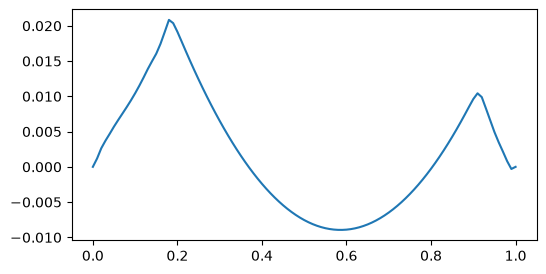

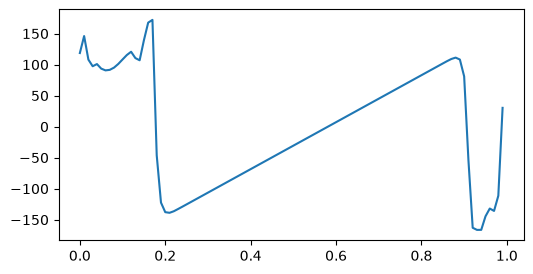

In [2]:
# This is an example of the unregularized solution

gparams = gropt.GroptParams()
gparams.N = 101
gparams.dt = 10e-6
gparams.vec_init_simple()

gparams.add_gmax(.08)
gparams.add_smax(200)
gparams.add_moment(0,2.0)
gparams.add_moment(1,0.0)
gparams.add_moment(2,0.0)

start_t = timer()
result = gropt.solve(gparams)
out = result.X
stop_t = timer()

print(f'Converged: {result.converged}   Solve time: {1000*(stop_t-start_t):.1f} ms')

TV_norm = np.abs(np.diff(out)).sum()
print(f'||g||_2 = {100*np.linalg.norm(out):.2}  ||Dg||_1 = {100*TV_norm:.2}')

plt.figure(figsize=(6,3))
tt_ms = np.arange(out.size)*gparams.dt*1e3
plt.plot(tt_ms, out)
plt.show()

plt.figure(figsize=(6,3))
plt.plot(tt_ms[:-1], np.diff(out)/gparams.dt)
plt.show()


Converged: True   Solve time: 30.1 ms
||g||_2 = 7.6  ||Dg||_1 = 5.7


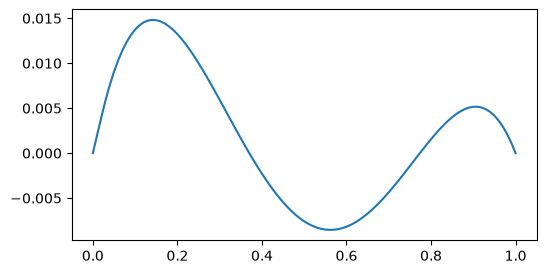

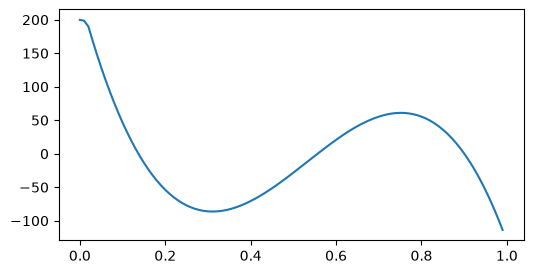

In [3]:
# Same parameters as the previous cell, with a total-variation (L1) penalty on the slew.

gparams = gropt.GroptParams()
gparams.N = 101
gparams.dt = 10e-6
gparams.vec_init_simple()

gparams.add_gmax(.08)
gparams.add_smax(200)
gparams.add_moment(0,2.0)
gparams.add_moment(1,0.0)
gparams.add_moment(2,0.0)

gparams.add_TV(100.0)

start_t = timer()
result = gropt.solve(gparams, min_iter=1000)
out = result.X
stop_t = timer()

print(f'Converged: {result.converged}   Solve time: {1000*(stop_t-start_t):.1f} ms')

TV_norm = np.abs(np.diff(out)).sum()
print(f'||g||_2 = {100*np.linalg.norm(out):.2}  ||Dg||_1 = {100*TV_norm:.2}')

plt.figure(figsize=(6,3))
tt_ms = np.arange(out.size)*gparams.dt*1e3
plt.plot(tt_ms, out)
plt.show()

plt.figure(figsize=(6,3))
plt.plot(tt_ms[:-1], np.diff(out)/gparams.dt)
plt.show()


Converged: True   Solve time: 17.9 ms
||g||_2 = 7.1  ||Dg||_1 = 6.5


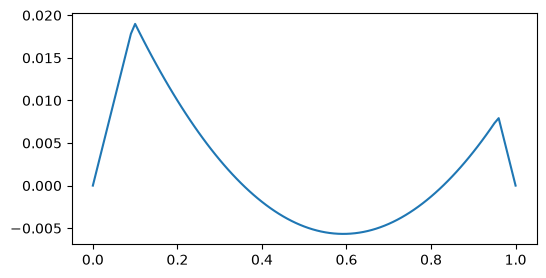

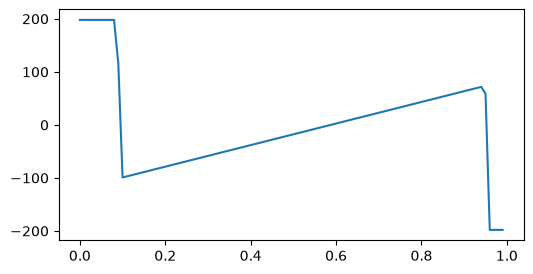

In [4]:
# Once again same parameters, but now we add a L2 regularization (during the CG step)

gparams = gropt.GroptParams()
gparams.N = 101
gparams.dt = 10e-6
gparams.vec_init_simple()

gparams.add_gmax(.08)
gparams.add_smax(200)
gparams.add_moment(0,2.0)
gparams.add_moment(1,0.0)
gparams.add_moment(2,0.0)

start_t = timer()
result = gropt.solve(gparams, min_iter=1000, ils_tik_lam=100000)
out = result.X
stop_t = timer()

print(f'Converged: {result.converged}   Solve time: {1000*(stop_t-start_t):.1f} ms')

TV_norm = np.abs(np.diff(out)).sum()
print(f'||g||_2 = {100*np.linalg.norm(out):.2}  ||Dg||_1 = {100*TV_norm:.2}')

plt.figure(figsize=(6,3))
tt_ms = np.arange(out.size)*gparams.dt*1e3
plt.plot(tt_ms, out)
plt.show()

plt.figure(figsize=(6,3))
plt.plot(tt_ms[:-1], np.diff(out)/gparams.dt)
plt.show()